In [1]:
# ─────────────────────────────────────────────
# [C1] ◀ ⚙️ 데이터 준비
# 최초 1회 다운로드 → data/ 폴더에 저장 (이후 오프라인)
# ─────────────────────────────────────────────
import urllib.request, zipfile
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import platform
import seaborn as sns
warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

system = platform.system()
if system == "Darwin":                      # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                                        # 코랩 등 리눅스 — 나눔고딕을 설치해야 합니다
    if not any("Nanum" in f.name for f in fm.fontManager.ttflist):
        print("나눔고딕을 설치합니다 (10~20초 걸립니다)...")
        import subprocess
        subprocess.run("apt-get install -y -qq fonts-nanum", shell=True,
                       capture_output=True)
        for path in fm.findSystemFonts(fontpaths=["/usr/share/fonts/truetype/nanum"]):
            fm.fontManager.addfont(path)
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지
sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"])


DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

def fetch_uci(url, zip_name, member):
    """UCI 정적 저장소의 zip을 내려받아 data/에 풀고, CSV 경로를 돌려줍니다."""
    csv_path = DATA_DIR / member
    if not csv_path.exists():
        zip_path = DATA_DIR / zip_name
        if not zip_path.exists():
            print(f"내려받는 중… {zip_name}")
            urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path) as z:
            z.extract(member, DATA_DIR)
    return csv_path

shoppers = pd.read_csv(fetch_uci(
    "https://archive.ics.uci.edu/static/public/468/online+shoppers+purchasing+intention+dataset.zip",
    "online_shoppers.zip", "online_shoppers_intention.csv"))

# 지난 순서와 동일한 수치형 10개 열 — 비교의 조건을 고정합니다
NUM_COLS = ["Administrative", "Administrative_Duration", "Informational",
            "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
            "BounceRates", "ExitRates", "PageValues", "SpecialDay"]

print(f"쇼핑 세션 데이터: {shoppers.shape[0]:,}행 × {shoppers.shape[1]}열")
print(f"구매 전환율: {shoppers['Revenue'].mean():.4f}")
print("\n→ 준비 완료. 이제 여러분 차례입니다.")

쇼핑 세션 데이터: 12,330행 × 18열
구매 전환율: 0.1547

→ 준비 완료. 이제 여러분 차례입니다.


In [2]:
# [C2] ◀ 문제 1. 단일 트리를 얹어 본다
# ⌨️ 문제 1 — 베이스라인 · 로지스틱 · 단일 트리를 나란히
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
# 여기에 코드를 작성하세요 (X, y 준비 → 분리 → 세 모델 학습 → 학습·테스트·격차 표)
X = shoppers[NUM_COLS]
y = shoppers['Revenue'].astype(int) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

rows = []

# 베이스라인 모델
dummy = DummyClassifier(random_state=RANDOM_STATE,strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_train = dummy.score(X_train, y_train)
dummy_test = dummy.score(X_test, y_test)
rows.append({
    "모델":"베이스라인",
    "학습 점수": dummy_train,
    "테스트 점수": dummy_test,
    "격차": dummy_train - dummy_test
})

# 로지스틱 회귀 모델
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # 학습 데이터로만 기준을 잡고
X_test_s = scaler.transform(X_test)         # 같은 기준으로 테스트 변환 (누수 방지!)

clf = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
clf.fit(X_train_s, y_train)

logit_train = clf.score(X_train_s, y_train)
logit_test = clf.score(X_test_s, y_test)
rows.append({
    "모델": "로지스틱",
    "학습 점수": logit_train,
    "테스트 점수": logit_test,
    "격차": logit_train - logit_test
})

# 단일 트리 모델
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt.fit(X_train, y_train)
dt_train = dt.score(X_train, y_train)
dt_test = dt.score(X_test, y_test)
rows.append({
    "모델": "단일 트리",
    "학습 점수": dt_train,
    "테스트 점수": dt_test,
    "격차": dt_train - dt_test
})
result_df = pd.DataFrame(rows)
result_df


,모델,학습 점수,테스트 점수,격차
0,베이스라인,0.845296,0.845093,0.000203
1,로지스틱,0.883921,0.879562,0.004359
2,단일 트리,0.999797,0.842255,0.157543


1. 복잡도가 제어되지 않았다
  - DecisionTreeClassifier(random_state=RANDOM_STATE)라고만 쓰면 아무 파라미터도 지정하지 않은것이기 때문에 트리의 정지조건은 **더 이상 나눌게 없을때까지 나눈다** 그래서 트리가 거의 외워버릴때까지 깊어지게 되서 특이한 조합까지 규칙으로 만들어 버린다. 이러면 전형적인 *과적합*곡선이 나온다

2. 베이스라인보다도 낮아진 이유
  - shoppers의 데이터가 불균형이라 꽤 놓은 점수를 그냥 먹고 들어간다. 단일트리는 과적합때문에 소수 클래스의 노이즈까지 전부 학습해버려서 오히려 새로운 데이터에서는 테스트 점수가 낮아진것이다

   max_depth     학습 점수    테스트 점수        격차
0        2.0  0.892234  0.886050  0.006184
1        3.0  0.893248  0.883212  0.010036
2        5.0  0.904907  0.894161  0.010746
3        8.0  0.925284  0.888078  0.037206
4       12.0  0.957218  0.874696  0.082522
5        NaN  0.999797  0.842255  0.157543

최고 테스트 점수 지점:
max_depth    5.000000
학습 점수        0.904907
테스트 점수       0.894161
격차           0.010746
Name: 2, dtype: float64


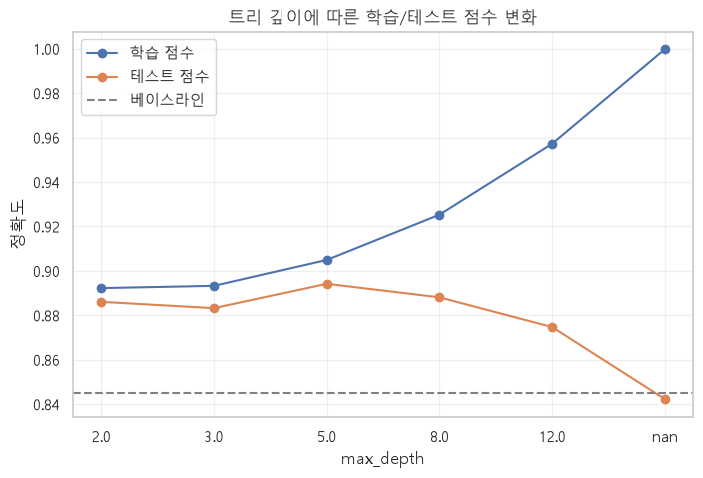

In [3]:
depths = [2, 3, 5, 8, 12, None]
rows = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    dt.fit(X_train, y_train)

    train_score = dt.score(X_train, y_train)
    test_score = dt.score(X_test, y_test)

    rows.append({
        "max_depth": depth,
        "학습 점수": train_score,
        "테스트 점수": test_score,
        "격차": train_score - test_score
    })

depth_df = pd.DataFrame(rows)
print(depth_df)

best_row = depth_df.loc[depth_df["테스트 점수"].idxmax()]
print("\n최고 테스트 점수 지점:")
print(best_row)

plot_depths = [20 if d is None else d for d in depths]

plt.figure(figsize=(8, 5))
plt.plot(range(len(depths)), depth_df["학습 점수"], marker="o", label="학습 점수")
plt.plot(range(len(depths)), depth_df["테스트 점수"], marker="o", label="테스트 점수")
plt.axhline(dummy_test, color="gray", linestyle="--", label="베이스라인")
plt.xticks(range(len(depths)), depth_df["max_depth"])  # 실제 라벨은 문자열(2,3,5,8,12,None)
plt.xlabel("max_depth")
plt.ylabel("정확도")
plt.title("트리 깊이에 따른 학습/테스트 점수 변화")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

1. 학습점수는 계속 좋아지지만 테스트 점수는 5를 기점으로 오히려 떨어지는 양상을 보인다. 이를 통해 점점 과적합되는 곡선을 확인할 수 있고 운인지 아닌지 가려내기 위해 교차검증을 시행해야 한다.

In [10]:
# [C4] ◀ 문제 3. 숲과 부스팅 — 4단 비교표를 완성한다
# ⌨️ 문제 3 — 랜덤포레스트·XGBoost를 더해 비교표 완성
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 여기에 코드를 작성하세요 (두 모델 학습 → 표에 추가 → 테스트 내림차순 출력)
results = []
def add(name, model, X_tr, X_te, y_tr=y_train, y_te=y_test):
    """모델 이름과 학습된 모델, 그에 맞는 X를 넘기면
    학습/테스트/격차를 계산해 results에 딕셔너리로 추가"""
    train_score = model.score(X_tr, y_tr)
    test_score = model.score(X_te, y_te)
    results.append({
        "모델": name,
        "학습": train_score,
        "테스트": test_score,
        "격차": train_score - test_score
    })

# ── 지금까지 만든 모델들을 표에 채우기 ──
add("① 베이스라인", dummy, X_train, X_test)
add("② 로지스틱", clf, X_train_s, X_test_s)          # 스케일링된 X 사용
add("③ 단일 트리(제한 없음)", dt, X_train, X_test)

# 가지치기(제어된) 트리도 있다면 이름에 설정을 명시해서 추가
dt_pruned = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
dt_pruned.fit(X_train, y_train)
add("③ 트리(max_depth=5)", dt_pruned, X_train, X_test)

random_forest = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
random_forest.fit(X_train, y_train)
add("④ 랜덤포레스트", random_forest, X_train, X_test)

xgb_boost = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=4, reg_lambda=1.0, eval_metric="logloss", random_state=RANDOM_STATE)
xgb_boost.fit(X_train, y_train)
add("⑤ XGBoost", xgb_boost, X_train, X_test)

result_df = pd.DataFrame(results).sort_values("테스트", ascending=False)
result_df

result_df.to_csv("model_comparison_v2.csv", index=False, encoding="utf-8-sig")

1. XGBoost보다 랜덤포레스트, 단일트리가 더 높은것을 볼 수 있다. 앙상블 모델은 강력하지만 데이터와 설정에 따라 다르므로 항상 비교표를 만들어봐야한다.

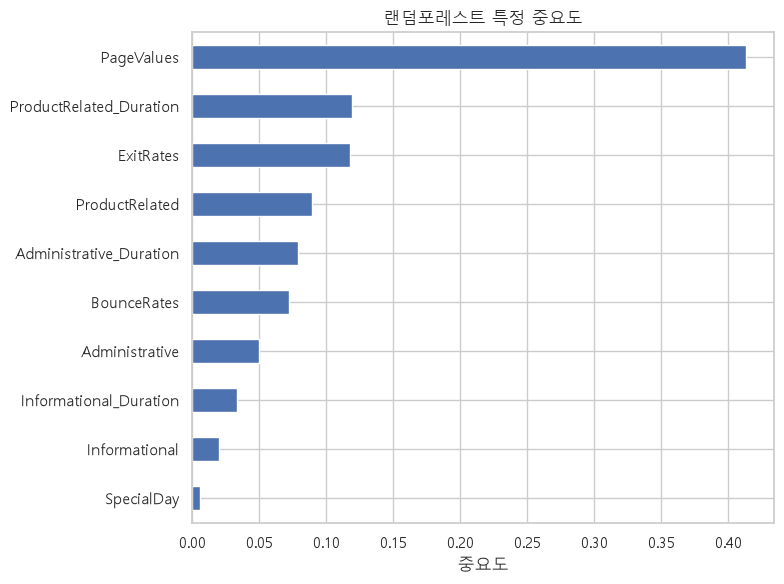

                   mean  size
PageValues_그룹                
0              0.038542  9600
0초과            0.563370  2730 

                  mean  size
ExitRates_그룹                
낮음            0.235199  6165
높음            0.074290  6165 

            mean  size
PRD_그룹                
낮음      0.086618  6165
높음      0.222871  6165 



In [7]:
# [C5] ◀ 문제 4. 피처 중요도를 비즈니스 언어로 옮긴다
# ⌨️ 문제 4 — 중요도 막대 + 상위 3개의 구매율 대비

# 여기에 코드를 작성하세요 (중요도 정렬·막대 → 상위 3개 구매율 비교)
imp = pd.Series(random_forest.feature_importances_, index=NUM_COLS)
imp.sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("랜덤포레스트 특정 중요도")
plt.xlabel("중요도")
plt.tight_layout()
plt.show()

shoppers["PageValues_그룹"] = np.where(shoppers["PageValues"] == 0, "0", "0초과")
pageValues = shoppers.groupby("PageValues_그룹")["Revenue"].agg(["mean", "size"])

exit_median = shoppers["ExitRates"].median()
shoppers["ExitRates_그룹"] = np.where(shoppers["ExitRates"] <= exit_median, "낮음", "높음")
exitRates = shoppers.groupby("ExitRates_그룹")["Revenue"].agg(["mean", "size"])

prd_median = shoppers["ProductRelated_Duration"].median()
shoppers["PRD_그룹"] = np.where(shoppers["ProductRelated_Duration"] <= prd_median, "낮음", "높음")
prd_duration = shoppers.groupby("PRD_그룹")["Revenue"].agg(["mean", "size"])

print(pageValues, "\n")
print(exitRates, "\n")
print(prd_duration, "\n")

1. 결과 해석
  - PageValues는 0일때 구매율이 고작 3.8%에 불과하지만 0초과인 그룹은 56%나 구매했다, 여기서 0은 페이지의 가치를 뜻한다. size는 보면 9600명으로 대부분 이 그룹에 속하지만 거의 안사고 2730명만 산다. 
  - ExitRates는 이탈율인데 이탈율이 낮을때 23%의 구매율을 보이고 이탈율이 높은 그룹은 구매율이 7%에 머무르는것을 확인할 수 있다
  - ProductRelated는 제품 관련 페이지에 오래 머문 그룹일수록 구매율이 22%이고 낮을수록 8.6%밖에 안되는것을 확인할 수 있다

2. 행동지표
  - 상위 세 피처들 모두 사용자의 행동기반지표라는 공통점이 있다. 반면 하위권에 머무른 피처들은 캘린더,카테고리성 변수라 개별 구매자의 구매 여부를 가르는 힘이 약하다

3. 주의할 점
  - 상관관계를 반드시 따져보아야한다.